# Text Classification

This notebook uses a small BERT model to classify short headlines as sarcastic or not sarcastic.


In [1]:
# The small sample text dataset used here is included in this repository.

In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load headline data

The included JSON lines file keeps the example small and easy to rerun.


In [3]:
df = pd.read_json('news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json', lines=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

(80, 3)


,article_link,headline,is_sarcastic
0,,Area man bravely opens another tab to solve al...,1
1,,Local student shocked that model trains better...,1
2,,Notebook claims it worked on my machine and re...,1
3,,Chart improves project morale by going upward,1
4,,Training loop says it has learned valuable les...,1


In [4]:
df.drop(columns='article_link', inplace = True)
df

,headline,is_sarcastic
0,Area man bravely opens another tab to solve al...,1
1,Local student shocked that model trains better...,1
2,Notebook claims it worked on my machine and re...,1
3,Chart improves project morale by going upward,1
4,Training loop says it has learned valuable les...,1
...,...,...
75,Pretrained backbones are often reused for visi...,0
76,Simple datasets are helpful for learning workf...,0
77,Model predictions can be compared with true la...,0
78,Training curves make model behavior easier to ...,0


In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    np.array(df['headline']),
    np.array(df['is_sarcastic']),
    test_size=0.3,
    stratify=np.array(df['is_sarcastic']),
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (56,)
X_test shape: (12,)
y_train shape: (56,)
y_test shape: (12,)
X_val shape: (12,)
y_val shape: (12,)


## Tokenize text

A lightweight BERT checkpoint is used for a practical demo.


In [6]:
from huggingface_hub.utils import logging as hf_logging
from transformers import logging as transformers_logging

hf_logging.set_verbosity_error()
transformers_logging.set_verbosity_error()

from huggingface_hub.utils import logging as hf_logging
from transformers import logging as transformers_logging

hf_logging.set_verbosity_error()
transformers_logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=False)
bert = AutoModel.from_pretrained("google/bert_uncased_L-2_H-128_A-2")

In [7]:
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
  def __init__(self, X, y):
    self.X = [tokenizer(x, max_length=100, truncation=True, padding="max_length", return_tensors='pt').to(device) for x in X]
    self.y = torch.tensor(y, dtype=torch.float).to(device)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

train_data = Data(X_train, y_train)
val_data = Data(X_val, y_val)
test_data = Data(X_test, y_test)

In [8]:
BATCH_SIZE = 8
EPOCHS = 12
LR = 5e-5

In [9]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

## Build the classifier

The BERT output is passed into a small neural network head.


In [10]:
class Zen(nn.Module):
  def __init__(self, bert):
    super(Zen, self).__init__()

    self.bert = bert
    self.drop = nn.Dropout(0.3)
    self.linear1 = nn.Linear(bert.config.hidden_size, 64)
    self.linear2 = nn.Linear(64, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, input_ids, attention_mask):
    pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[0][:,0]
    output = self.linear1(pooled_output)
    output = self.drop(output)
    output = self.linear2(output)
    output = self.sigmoid(output)

    return output

In [11]:
for params in bert.parameters():
  params.requires_grad = True
model = Zen(bert).to(device)

In [12]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=LR)

In [13]:
loss_train = []
loss_val = []
acc_train = []
acc_val = []

for epoch in range(EPOCHS):
  total_loss_train = 0
  total_acc_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train()

  model.train()

  model.train()

  for idx, data in enumerate(train_loader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    loss = loss_fn(preds, labels)
    total_loss_train += loss.item()

    acc = (preds.round() == labels).sum().item()
    total_acc_train += acc

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  model.eval()
  model.eval()
  model.eval()
  with torch.no_grad():
    for idx, data in enumerate(val_loader):
      inputs, labels = data
      inputs.to(device)
      labels.to(device)

      preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)

      loss = loss_fn(preds, labels)
      total_loss_val += loss.item()

      acc = (preds.round() == labels).sum().item()
      total_acc_val += acc
  loss_train.append(round(total_loss_train/len(train_loader), 4))
  loss_val.append(round(total_loss_val/len(val_loader), 4))
  acc_train.append(round((total_acc_train/train_data.__len__()) * 100,4))
  acc_val.append(round((total_acc_val/val_data.__len__()) * 100, 4))

  print(f"Epoch: {epoch+1}/{EPOCHS}")
  print(f"Train Loss: {loss_train[-1]} | Train Acc: {acc_train[-1]}")
  print(f"Val Loss: {loss_val[-1]} | Val Acc: {acc_val[-1]}")

Epoch: 1/12
Train Loss: 0.7465 | Train Acc: 48.2143
Val Loss: 0.6637 | Val Acc: 50.0


Epoch: 2/12
Train Loss: 0.6744 | Train Acc: 55.3571
Val Loss: 0.594 | Val Acc: 83.3333


Epoch: 3/12
Train Loss: 0.6553 | Train Acc: 60.7143
Val Loss: 0.5628 | Val Acc: 100.0


Epoch: 4/12
Train Loss: 0.6086 | Train Acc: 71.4286
Val Loss: 0.5523 | Val Acc: 91.6667


Epoch: 5/12
Train Loss: 0.5751 | Train Acc: 80.3571
Val Loss: 0.5151 | Val Acc: 100.0


...

Epoch: 8/12
Train Loss: 0.4821 | Train Acc: 83.9286
Val Loss: 0.4691 | Val Acc: 91.6667


Epoch: 9/12
Train Loss: 0.4103 | Train Acc: 91.0714
Val Loss: 0.4058 | Val Acc: 91.6667


Epoch: 10/12
Train Loss: 0.3999 | Train Acc: 89.2857
Val Loss: 0.4073 | Val Acc: 91.6667


Epoch: 11/12
Train Loss: 0.3341 | Train Acc: 89.2857
Val Loss: 0.3793 | Val Acc: 91.6667


Epoch: 12/12
Train Loss: 0.2427 | Train Acc: 100.0
Val Loss: 0.2952 | Val Acc: 91.6667


## Test the model

The test split is used for a final accuracy check.


In [14]:
model.eval()
model.eval()
model.eval()
with torch.inference_mode():
  total_acc_test = 0
  total_loss_test = 0
  for idx, data in enumerate(test_loader):
    inputs, labels = data
    inputs.to(device)
    labels.to(device)

    preds = model(inputs['input_ids'].squeeze(1), inputs['attention_mask'].squeeze(1)).squeeze(1)
    loss = loss_fn(preds, labels)
    total_loss_test += loss.item()

    acc = (preds.round() == labels).sum().item()
    total_acc_test += acc

  print(f"Test Loss: {round(total_loss_test/test_data.__len__(),4)} | Test Acc: {round((total_acc_test/test_data.__len__()) * 100,4)}")


Test Loss: 0.0559 | Test Acc: 91.6667


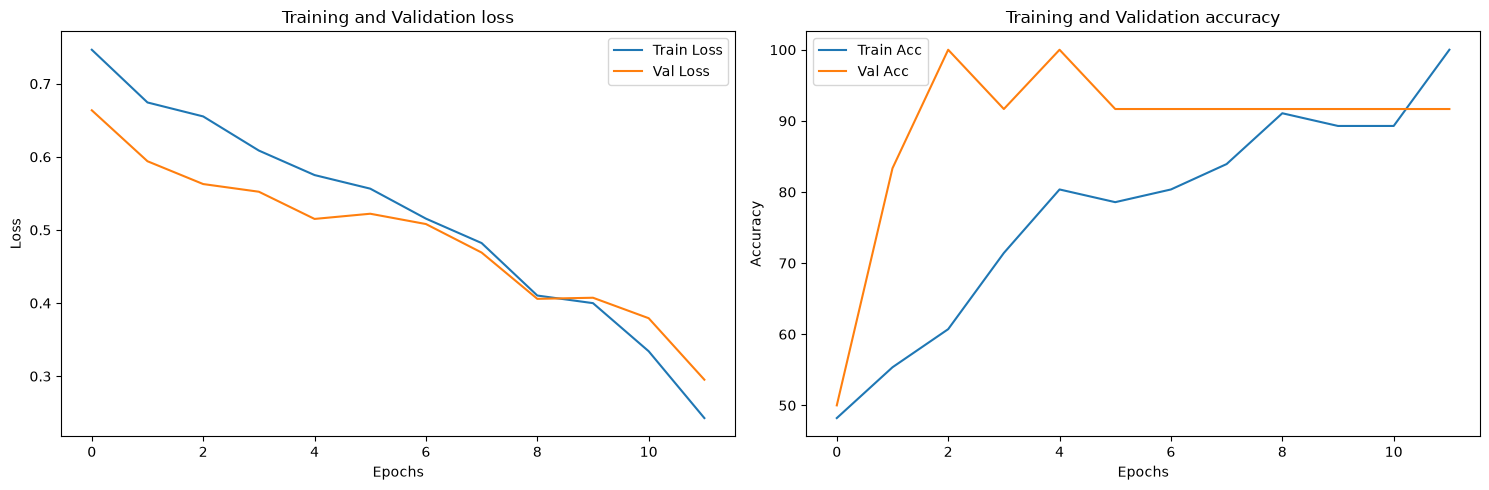

In [15]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(loss_train, label='Train Loss')
axs[0].plot(loss_val, label='Val Loss')
axs[0].set_title('Training and Validation loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(acc_train, label='Train Acc')
axs[1].plot(acc_val, label='Val Acc')
axs[1].set_title('Training and Validation accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()